In [126]:
import os
import pandas as pd
from datetime import datetime
import importlib
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [127]:
# Relative imports
d = os.path.abspath(os.getcwd())
os.chdir("../..")
import hidden_state_model.processor
importlib.reload(hidden_state_model.processor)
Processor = hidden_state_model.processor.Processor
os.chdir(d)

### Read (and compact) dataframes

In [128]:
compact = False

In [129]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
data_dir = os.path.join(d, "..", "data")
for file in os.listdir(data_dir):
    fname = os.path.join(data_dir, file)
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(fname)
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(fname, index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs)

if compact and len(dfs) > 10:
    print("Compacintg dfs")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(os.path.join(data_dir, f"combined_{timestamp}.parquet"))

    # Move files already in trash to trash within trash
    trash = os.path.join(data_dir, "trash")
    trash_in_trash = os.path.join(trash, f"trash_{timestamp}")
    os.makedirs(trash_in_trash, exist_ok=True)
    for f in os.listdir(trash):
        if f.endswith(".parquet") or f.endswith(".csv"):
            os.rename(os.path.join(trash, f), os.path.join(trash_in_trash, f))
    
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    for f in read:
        os.rename(os.path.join(data_dir, f), os.path.join(trash, f))

dfs = []  # Clear memory
raw_df

Reading maxevplayer-2024-09-30_22-46-13.parquet
Reading combined_20240930223444.parquet


,prev_entry,public_cards,player_piles,current_player_i,bet_in_stage,bet_in_game,player_has_played,player_is_folded,first_better_i,big_blind,...,player_type,opponent_names,action,amount,p,relative_ev,rank,tiebreakers,hand_index,state_id
state_id,,,,,,,,,,,,,,,,,,,,,
4226a909-0c78-43b3-b633-fbd43c914ac3,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,MaxEVPlayer,[Adrian],raise,6,0.6265,0.018795,0,"[12, 10, 0, 0, 0]",582.0,NaN
1b3a4c91-84f2-4714-ac8b-ce0cd2e09bee,None,[],"[92, 96]",1,"[8, 4]","[8, 4]","[True, False]","[False, False]",0,4,...,MaxEVPlayer,[Max Mekker],raise,8,0.5728,0.034368,0,"[9, 8, 0, 0, 0]",406.0,NaN
9856e545-8283-4a46-8c71-36bcbb6ca174,4226a909-0c78-43b3-b633-fbd43c914ac3,[],"[92, 88]",0,"[8, 12]","[8, 12]","[True, True]","[False, False]",0,4,...,MaxEVPlayer,[Adrian],raise,12,0.6265,0.062650,0,"[12, 10, 0, 0, 0]",582.0,NaN
847a3458-f3e0-41c8-a750-d64f486939f4,1b3a4c91-84f2-4714-ac8b-ce0cd2e09bee,[],"[80, 88]",1,"[20, 12]","[20, 12]","[True, True]","[False, False]",0,4,...,MaxEVPlayer,[Max Mekker],raise,12,0.5728,0.091648,0,"[9, 8, 0, 0, 0]",406.0,NaN
75596cb2-fbd0-4c58-8c54-8ccfa00d170f,9856e545-8283-4a46-8c71-36bcbb6ca174,[],"[80, 76]",0,"[20, 24]","[20, 24]","[True, True]","[False, False]",0,4,...,MaxEVPlayer,[Adrian],call,4,0.6265,0.137830,0,"[12, 10, 0, 0, 0]",582.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8a3533f2-e424-439e-9554-80fd7ebd6d77,None,[],"[80, 114]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],fold,0,0.5005,0.015015,0,"[9, 2, 0, 0, 0]",1069.0,NaN
967e17e0-39a0-41bb-bdb9-7db2999d59f3,None,[],"[76, 116]",0,"[4, 4]","[4, 4]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],check,0,0.4033,0.016132,0,"[3, 1, 0, 0, 0]",637.0,NaN
0919cd80-2bcd-4830-bd3d-a1ba8539652f,967e17e0-39a0-41bb-bdb9-7db2999d59f3,"[21, 24, 35]","[76, 112]",0,"[0, 4]","[4, 8]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],raise,20,0.3088,0.018528,0,"[11, 9, 8, 3, 1]",637.0,NaN


In [130]:
raw_df.dtypes

prev_entry            object
public_cards          object
player_piles          object
current_player_i       int64
bet_in_stage          object
bet_in_game           object
player_has_played     object
player_is_folded      object
first_better_i         int64
big_blind              int64
player_name           object
player_type           object
opponent_names        object
action                object
amount                 int64
p                    float64
relative_ev          float64
rank                   int64
tiebreakers           object
hand_index           float64
state_id             float64
dtype: object

In [131]:
# Check for conflicting rows
dupe_df = raw_df[raw_df.index.duplicated()]
assert len(dupe_df) == 0, dupe_df

## Process data

In [132]:
processor = Processor(raw_df)
df = processor.get_processed_df()
df

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,action,amount,excess_rank,p,relative_ev,stage,player_name,opponent_name,n_players,is_all_in
6076184224,0,0,0,0,0,0,0,0,0,0,...,call,2,0,0.5985,0.017955,preflop,Tord,,2,False
5770114048,0,0,0,0,0,0,0,0,0,0,...,call,2,0,0.6170,0.018510,preflop,Arin,,2,False
6167147184,0,0,0,0,0,0,0,0,0,0,...,raise,6,0,0.5631,0.016893,preflop,Arin Bavian,,2,False
6d7b5bfe-d92a-48cd-9dfa-a12e12e6685c,0,0,0,0,0,0,0,0,0,0,...,fold,0,0,0.4939,0.029634,preflop,Henning,Max Mekker,2,False
6076273520,0,0,0,0,0,0,0,0,0,0,...,call,2,0,0.5014,0.015042,preflop,Tord,,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6162184512,0,22,21,0,0,6,5,10,0,0,...,check,0,1,0.8571,0.565686,river,Arin,,2,False
6137322224,0,0,57,0,0,7,7,0,0,0,...,check,0,2,0.9750,0.711750,river,Arin,,2,True
4693928928,0,0,0,0,0,6,9,4,0,0,...,check,0,0,0.5191,0.109011,river,Arin,,2,False
6126809296,0,0,0,0,0,6,7,6,0,0,...,call,19,1,0.5474,0.166957,river,Arin,,2,False


In [133]:
df.dtypes

raise_preflop                int64
raise_flop                   int64
raise_turn                   int64
raise_river                  int64
raise_showdown               int64
call_preflop                 int64
call_flop                    int64
call_turn                    int64
call_river                   int64
call_showdown                int64
check_preflop                int64
check_flop                   int64
check_turn                   int64
check_river                  int64
check_showdown               int64
opponent_raise_preflop       int64
opponent_raise_flop          int64
opponent_raise_turn          int64
opponent_raise_river         int64
opponent_raise_showdown      int64
opponent_call_preflop        int64
opponent_call_flop           int64
opponent_call_turn           int64
opponent_call_river          int64
opponent_call_showdown       int64
opponent_check_preflop       int64
opponent_check_flop          int64
opponent_check_turn          int64
opponent_check_river

## Training

In [134]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

In [135]:
X = df.drop(["excess_rank", "game_id", "p", "relative_ev"], axis=1)
y = df["p"]
groups = df["game_id"]  # Group by 'game_id' to ensure no data leakage

In [136]:
X

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,opponent_check_turn,opponent_check_river,opponent_check_showdown,action,amount,stage,player_name,opponent_name,n_players,is_all_in
6076184224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,call,2,preflop,Tord,,2,False
5770114048,0,0,0,0,0,0,0,0,0,0,...,0,0,0,call,2,preflop,Arin,,2,False
6167147184,0,0,0,0,0,0,0,0,0,0,...,0,0,0,raise,6,preflop,Arin Bavian,,2,False
6d7b5bfe-d92a-48cd-9dfa-a12e12e6685c,0,0,0,0,0,0,0,0,0,0,...,0,0,0,fold,0,preflop,Henning,Max Mekker,2,False
6076273520,0,0,0,0,0,0,0,0,0,0,...,0,0,0,call,2,preflop,Tord,,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6162184512,0,22,21,0,0,6,5,10,0,0,...,1,1,0,check,0,river,Arin,,2,False
6137322224,0,0,57,0,0,7,7,0,0,0,...,1,0,0,check,0,river,Arin,,2,True
4693928928,0,0,0,0,0,6,9,4,0,0,...,1,1,0,check,0,river,Arin,,2,False
6126809296,0,0,0,0,0,6,7,6,0,0,...,1,1,0,call,19,river,Arin,,2,False


In [137]:
y

6076184224                              0.5985
5770114048                              0.6170
6167147184                              0.5631
6d7b5bfe-d92a-48cd-9dfa-a12e12e6685c    0.4939
6076273520                              0.5014
                                         ...  
6162184512                              0.8571
6137322224                              0.9750
4693928928                              0.5191
6126809296                              0.5474
6137690960                              0.9647
Name: p, Length: 6948, dtype: float64

In [138]:
# Identify categorical columns (excluding 'game_id')
categorical_cols = ["action", "stage", "player_name", "opponent_name"]

# Preprocessing pipeline: OneHotEncoding for categorical and scaling for numerical
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough",
)

# Create the full pipeline with logistic regression
model = Pipeline(
    [
        ("preprocess", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

In [139]:
# Grouped train-test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (5576, 37)
Test shape: (1372, 37)


In [140]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor', LinearRegression())])

In [141]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df

RMSE: 0.15879586031905413
MAE: 0.12046373796070965
MAPE: 37.62%


,y_test,y_pred
6076184224,0.5985,0.524629
10976139824,0.6015,0.530499
6148857040,0.3471,0.416151
45169c73-d133-4d34-b3e9-d33a7282c9c6,0.3949,0.668596
94ff3a0f-c4c5-469f-876c-81fa7adeac0f,0.5215,0.522755
...,...,...
6299785584,0.1990,0.568358
6090895424,0.4951,0.524419
4693928928,0.5191,0.522487
6126809296,0.5474,0.474936


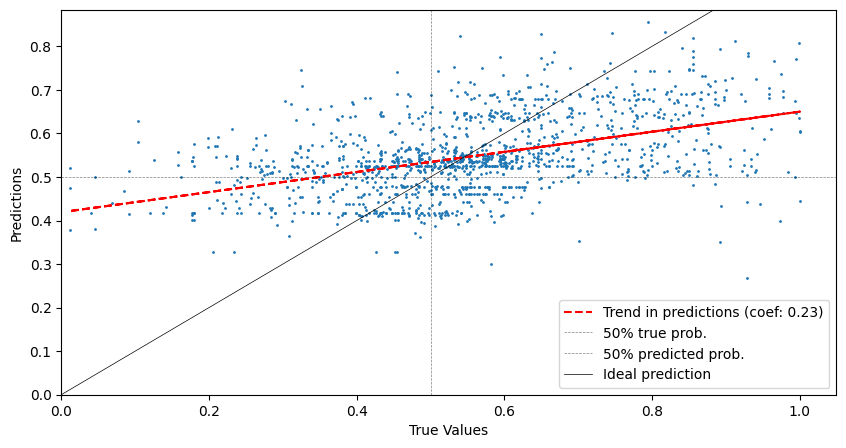

In [142]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()

### Examine feature importance

In [143]:
# Calculate feature importance
# Get the one-hot encoded feature names
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([feature_names, X.columns[len(categorical_cols):]])

coefs = model.named_steps["regressor"].coef_

# Sort by absolute value
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)
coef_df

,feature,coef,abs_coef
21,raise_showdown,-4.263032e+11,4.263032e+11
41,opponent_call_showdown,4.263032e+11,4.263032e+11
23,call_flop,6.341874e+10,6.341874e+10
43,opponent_check_flop,-6.341874e+10,6.341874e+10
18,opponent_name_Adrian,-2.541997e+10,2.541997e+10
14,player_name_Max Mekker,2.541997e+10,2.541997e+10
22,call_preflop,-1.587558e+10,1.587558e+10
42,opponent_check_preflop,1.587558e+10,1.587558e+10
24,call_turn,8.309783e+08,8.309783e+08
44,opponent_check_turn,-8.309783e+08,8.309783e+08


### Compare to XGBoost

In [144]:
from xgboost import XGBRegressor

# Create the full pipeline with XGBoost
model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "regressor",
            XGBRegressor(
                colsample_bytree=0.6,
                learning_rate=0.1,
                max_depth=3,
                n_estimators=500,
                subsample=1.0,
            ),
        ),
    ]
)

In [145]:
cross_validate = False

In [146]:
if cross_validate:
    # Cross validate to find good hyperparameters
    from sklearn.model_selection import GridSearchCV

    # Define the parameter grid
    param_grid = {
        'regressor__n_estimators': [100, 500],
        'regressor__learning_rate': [0.01, 0.1],
        'regressor__max_depth': [3, 5, 7],
        'regressor__subsample': [0.6, 0.8, 1.0],
        'regressor__colsample_bytree': [0.6, 0.8, 1.0],
    }

    # Grid search over the XGBRegressor parameters
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')

    # Fit the model
    grid_search.fit(X_train, y_train)

    # Best parameters and score
    print(grid_search.best_params_)
    print(grid_search.best_score_)
    
    # Use the best model
    model = grid_search.best_estimator_

In [147]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name',
                                                   'opponent_name'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.6, device=None,
                              early_stopping_rounds=None,
                              e...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [148]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df["player_name"] = df.iloc[test_idx]["player_name"]
pred_df

RMSE: 0.16059498141462494
MAE: 0.11886890907296721
MAPE: 36.71%


,y_test,y_pred,player_name
6076184224,0.5985,0.509461,Tord
10976139824,0.6015,0.578112,Arin
6148857040,0.3471,0.432345,Arin
45169c73-d133-4d34-b3e9-d33a7282c9c6,0.3949,0.608310,Jakob
94ff3a0f-c4c5-469f-876c-81fa7adeac0f,0.5215,0.570818,Finn
...,...,...,...
6299785584,0.1990,0.281185,Arin
6090895424,0.4951,0.297932,Arin
4693928928,0.5191,0.421194,Arin
6126809296,0.5474,0.365860,Arin


In [149]:
pred_df["square"] = (pred_df["y_test"] - pred_df["y_pred"])**2
(pred_df.pivot_table("square", "player_name", aggfunc="mean")**(1/2)).sort_values(by="square")

,square
player_name,
Adrian,0.075050
Kristian,0.089747
Arin Bavian,0.104733
Henning,0.136803
Jacob,0.138839
Alun,0.148404
Arin,0.157953
Tord,0.162362
Syver,0.166715


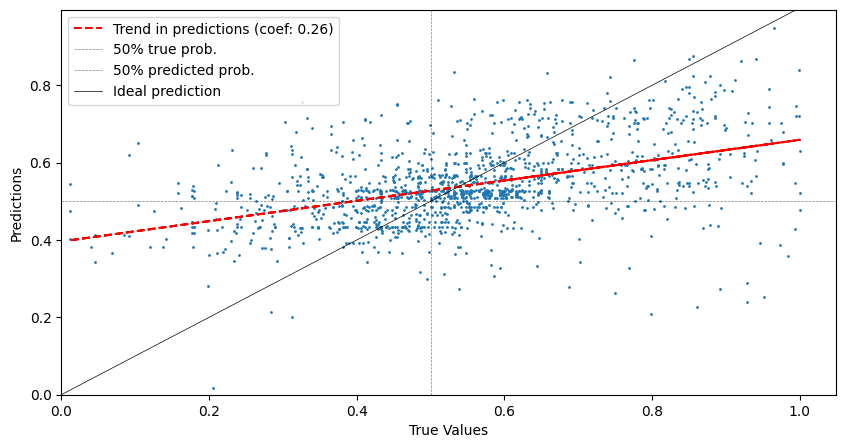

In [150]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()

In [151]:
# Examine feature importance
# Get the one-hot encoded feature names
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([feature_names, X.columns[len(categorical_cols):]])

# Get the feature importances
importances = model.named_steps["regressor"].feature_importances_

# Sort by importance
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False)
importance_df

,feature,importance
2,action_raise,0.207789
1,action_fold,0.111083
3,stage_preflop,0.056622
34,opponent_raise_turn,0.046203
22,call_preflop,0.031672
51,opponent_name,0.029536
47,action,0.025079
43,opponent_check_flop,0.021933
19,opponent_name_Max Mekker,0.019980
48,amount,0.019887
